In [1]:
# =====================================================================
# Particula cargada + delta de Dirac modificada (Polonyi, arXiv:1701.04068)
#
# Dos interruptores independientes:
#   RETARDO   ell > 0   separa los puntos: delta_B(z) deja de apoyarse en el cono
#   SUAVIZADO True/False  ec. (5) delta ancha  /  ec. (4) delta desplazada
#
# Autocontenido: numpy, scipy, matplotlib. Signatura (+,-), c = 1, r0 = 1.
# =====================================================================
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq
import matplotlib.pyplot as plt

ELL       = 0.5     # retardo del point-splitting, en unidades de r0
SUAVIZADO = True    # True: ec. (5)   False: ec. (4)
AMP       = 0.6     # amplitud de la rapidez.  AMP = 0 es la PARTICULA LIBRE
S0, SIGMA = 0.0, 1.0

In [2]:
def punto(a, b):
    """Producto de Minkowski (+,-) en 1+1, sobre el ultimo eje."""
    return a[..., 0] * b[..., 0] - a[..., 1] * b[..., 1]


def magnitud(a):
    """|a| invariante de un vector ESPACIAL: sqrt(-a.a).

    La autofuerza es ortogonal a xdot (timelike), luego siempre espacial. Usar
    la norma euclidea aqui daria un numero dependiente del marco.
    """
    return np.sqrt(np.maximum(-punto(a, a), 0.0))


def linea_de_mundo(amp, s_min=-60.0, s_max=8.0, ds=1e-3):
    """Trayectoria prescrita con xdot^2 = 1 EXACTO. Devuelve splines (x, xdot, xddot).

    Se parametriza por la rapidez eta(s), no por las componentes: asi
    xdot = (cosh eta, sinh eta) cumple xdot^2 = 1 identicamente y la
    normalizacion no depende del paso. amp = 0 da eta = 0: la particula libre.
    """
    s = np.arange(s_min, s_max + ds, ds)
    eta = amp * np.exp(-((s - S0) / SIGMA) ** 2)
    deta = -2.0 * (s - S0) / SIGMA ** 2 * eta
    v = np.stack([np.cosh(eta), np.sinh(eta)], axis=1)
    a = deta[:, None] * np.stack([np.sinh(eta), np.cosh(eta)], axis=1)
    x = np.vstack([np.zeros(2), np.cumsum(0.5 * (v[1:] + v[:-1]) * ds, axis=0)])
    return CubicSpline(s, x), CubicSpline(s, v), CubicSpline(s, a)

In [3]:
def dd_suavizado(z, ell):
    """delta_B'(z) de la ec. (5): [1 - sqrt(z)/2ell] exp(-sqrt(z)/ell) / 12 ell^4."""
    r = np.sqrt(np.maximum(z, 0.0))
    return np.where(z > 0.0, (1 - r / (2*ell)) * np.exp(-r/ell) / (12 * ell**4), 0.0)


def _V(d, v, vp):
    """(x-x')(xdot.xdot') - [xdot.(x-x')] xdot'.

    ESTE es el objeto que decide todo: se anula IDENTICAMENTE cuando el
    movimiento es inercial, porque entonces xdot' = xdot y (x-x') es paralelo
    a xdot. Una carga libre no radia, encendamos la delta que encendamos.
    """
    return d * punto(v, vp)[..., None] - punto(v, d)[..., None] * vp

In [4]:
def autofuerza(s_now, X, V_, ell=ELL, suavizado=SUAVIZADO, r0B=1.0,
               n_ell=30.0, pts_por_ell=16):
    """xddot = 4 r_0B int ds' delta_B'((x-x')^2) V,  ec. (6) del paper."""
    if ell <= 0:
        raise ValueError(
            "ell = 0 es la teoria LOCAL: delta_B se apoya en el cono de luz y la "
            "autofuerza diverge. Apagar el retardo del todo no da un numero; ese "
            "es justamente el problema que el point-splitting resuelve.")

    x, v = X(s_now), V_(s_now)

    if suavizado:
        # Ec. (5): la delta tiene ancho, asi que contribuye el pasado ENTERO.
        n = int(np.ceil(n_ell * pts_por_ell)) | 1        # Simpson necesita impar
        sp = np.linspace(s_now - n_ell * ell, s_now, n)
        d = x - X(sp)
        integ = dd_suavizado(np.maximum(punto(d, d), 0.0), ell)[:, None] * _V(d, v, V_(sp))
        pesos = np.ones(n); pesos[1:-1:2] = 4.0; pesos[2:-1:2] = 2.0
        I = ((sp[1] - sp[0]) / 3.0) * np.einsum("i,ij->j", pesos, integ)
    else:
        # Ec. (4): delta(w - ell^2). Contribuye UN SOLO punto del pasado, pero
        # lo que aparece es delta', asi que alli se evalua una DERIVADA:
        #   int ds' delta'(W) V = d/ds'[V/W'] / W'  en W = 0,  con W = w - ell^2.
        w = lambda sp: punto(x - X(sp), x - X(sp))
        s_ret = brentq(lambda sp: w(sp) - ell**2, s_now - 40.0*max(ell, 1.0), s_now - 1e-9)
        g = lambda sp: _V(x - X(sp), v, V_(sp)) / (-2.0 * punto(x - X(sp), V_(sp)))
        h = 1e-4
        I = (g(s_ret + h) - g(s_ret - h)) / (2*h) / (-2.0 * punto(x - X(s_ret), V_(s_ret)))

    return 4.0 * r0B * I

In [5]:
# --- TEST: la particula LIBRE. Encender las deltas no debe hacer nada. ---
Xl, Vl, Al = linea_de_mundo(amp=0.0)
print("PARTICULA LIBRE  (AMP = 0)")
for ell in (2.0, 1.0, 0.5, 0.1):
    for suav in (True, False):
        f = autofuerza(0.0, Xl, Vl, ell=ell, suavizado=suav)
        print(f"  ell={ell:4.1f}  suavizado={str(suav):5s}   |xddot| = {magnitud(f):.3e}")
print("\nCero EXACTO, no aproximado: V se anula identicamente para movimiento inercial.")
print("Si alguna de estas filas no da 0.000e+00, hay un error en el codigo.")

PARTICULA LIBRE  (AMP = 0)
  ell= 2.0  suavizado=True    |xddot| = 0.000e+00
  ell= 2.0  suavizado=False   |xddot| = 0.000e+00
  ell= 1.0  suavizado=True    |xddot| = 0.000e+00
  ell= 1.0  suavizado=False   |xddot| = 0.000e+00
  ell= 0.5  suavizado=True    |xddot| = 0.000e+00
  ell= 0.5  suavizado=False   |xddot| = 0.000e+00
  ell= 0.1  suavizado=True    |xddot| = 0.000e+00
  ell= 0.1  suavizado=False   |xddot| = 0.000e+00

Cero EXACTO, no aproximado: V se anula identicamente para movimiento inercial.
Si alguna de estas filas no da 0.000e+00, hay un error en el codigo.


In [6]:
# --- Con la particula acelerada los interruptores SI hacen algo ---
X, V_, A_ = linea_de_mundo(amp=AMP)
print(f"ACELERADA (AMP = {AMP}),  |xddot| evaluada en s = 0\n")
print(f"{'r0/ell':>7} {'ell':>6} {'suavizado ec.(5)':>18} {'desplazado ec.(4)':>19}")
for ell in (2.0, 1.0, 0.5, 0.25, 0.125):
    a = magnitud(autofuerza(0.0, X, V_, ell=ell, suavizado=True))
    b = magnitud(autofuerza(0.0, X, V_, ell=ell, suavizado=False))
    print(f"{1/ell:7.2f} {ell:6.3f} {a:18.6e} {b:19.6e}")
print("\nOjo: en s = 0 la aceleracion prescrita se anula, asi que aqui NO se ve")
print("el contratermino de masa. Para eso hay que evaluar donde xddot != 0.")

ACELERADA (AMP = 0.6),  |xddot| evaluada en s = 0

 r0/ell    ell   suavizado ec.(5)   desplazado ec.(4)
   0.50  2.000       3.067955e-03        3.598015e-02
   1.00  1.000       1.790394e-03        2.010739e-01
   2.00  0.500       5.866629e-02        5.827179e-01
   4.00  0.250       2.824621e-01        7.412718e-01
   8.00  0.125       5.703250e-01        7.850761e-01

Ojo: en s = 0 la aceleracion prescrita se anula, asi que aqui NO se ve
el contratermino de masa. Para eso hay que evaluar donde xddot != 0.


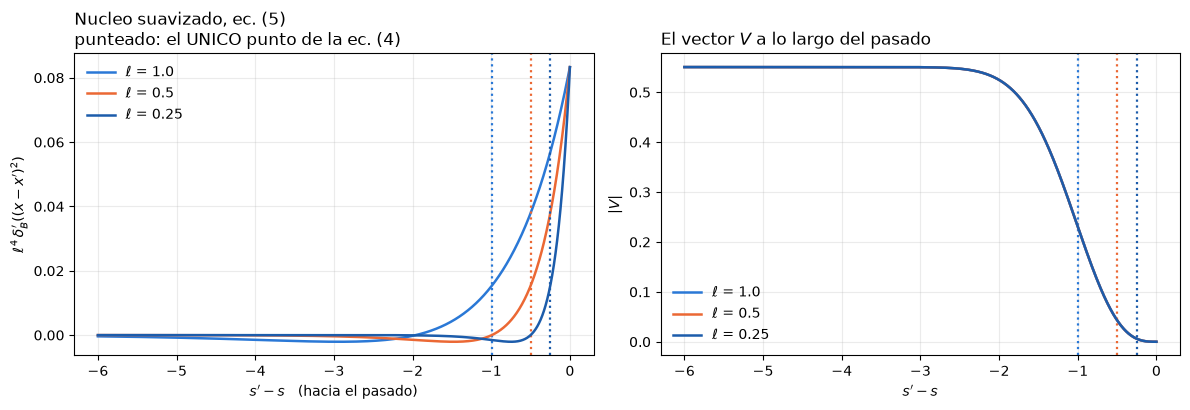

In [7]:
# --- Que hace exactamente el suavizado: DONDE muestrea el pasado ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
u = np.linspace(-6.0, -1e-4, 2000)          # s' - s, hacia el pasado
x0, v0 = X(0.0), V_(0.0)
d = x0 - X(u); w = np.maximum(punto(d, d), 0.0)

for ell, col in zip((1.0, 0.5, 0.25), ("#2a78d6", "#eb6834", "#1c5cab")):
    ax1.plot(u, dd_suavizado(w, ell) * ell**4, lw=1.8, color=col, label=f"$\\ell$ = {ell}")
    s_ret = brentq(lambda sp: punto(x0 - X(sp), x0 - X(sp)) - ell**2, -40.0, -1e-9)
    ax1.axvline(s_ret, color=col, ls=":", lw=1.6)
    ax2.plot(u, magnitud(_V(d, v0, V_(u))), lw=1.8, color=col,
             label=f"$\\ell$ = {ell}")
    ax2.axvline(s_ret, color=col, ls=":", lw=1.6)

ax1.set_xlabel("$s' - s$   (hacia el pasado)")
ax1.set_ylabel("$\\ell^4\\,\\delta_B'((x-x')^2)$")
ax1.set_title("Nucleo suavizado, ec. (5)\npunteado: el UNICO punto de la ec. (4)", loc="left")
ax2.set_xlabel("$s' - s$"); ax2.set_ylabel("$|V|$")
ax2.set_title("El vector $V$ a lo largo del pasado", loc="left")
for a in (ax1, ax2):
    a.legend(frameon=False); a.grid(alpha=.25); a.set_axisbelow(True)
plt.tight_layout(); plt.show()

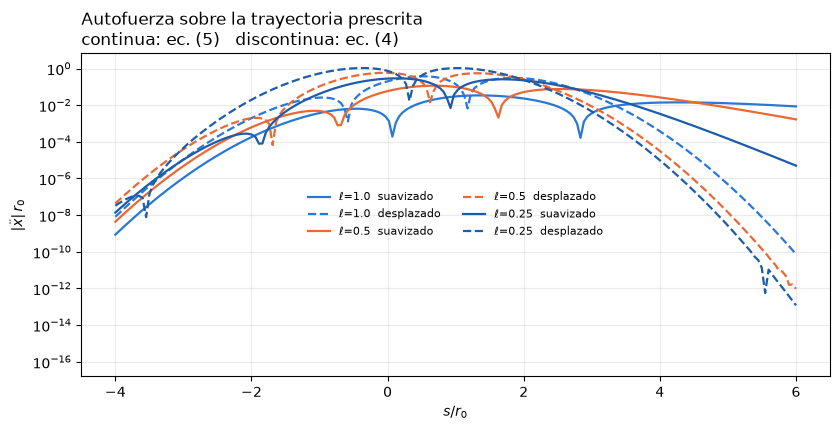

In [8]:
# --- La autofuerza a lo largo de la trayectoria, con los dos interruptores ---
ss = np.linspace(-4.0, 6.0, 200)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
for ell, col in zip((1.0, 0.5, 0.25), ("#2a78d6", "#eb6834", "#1c5cab")):
    for suav, ls in ((True, "-"), (False, "--")):
        y = [magnitud(autofuerza(s, X, V_, ell=ell, suavizado=suav)) for s in ss]
        ax.semilogy(ss, np.maximum(y, 1e-16), ls, lw=1.6, color=col,
                    label=f"$\\ell$={ell}  {'suavizado' if suav else 'desplazado'}")
ax.plot(ss, np.abs([A_(s)[1] for s in ss]) * 0 + 1e-16, alpha=0)   # ancla del eje
ax.set_xlabel("$s / r_0$"); ax.set_ylabel("$|\\ddot{x}|\\, r_0$")
ax.set_title("Autofuerza sobre la trayectoria prescrita\n"
             "continua: ec. (5)   discontinua: ec. (4)", loc="left")
ax.legend(frameon=False, fontsize=8, ncol=2); ax.grid(alpha=.25); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [9]:
# --- Apagar el retardo del todo: de donde sale el contratermino de masa ---
try:
    autofuerza(0.0, X, V_, ell=0.0)
except ValueError as e:
    print("ell = 0:", e)

# Evaluado donde la aceleracion prescrita NO se anula, la autofuerza diverge
# como 1/ell, y el coeficiente es exactamente delta_m de la ec. (10):
#     delta_m/m = r0/(6 ell)  suavizado      r0/(2 ell)  desplazado
# Restando delta_m * xddot queda un resto FINITO e independiente del cutoff.
S_EVAL = 1.0
acc = magnitud(A_(S_EVAL))
print(f"\ns = {S_EVAL},  |xddot| prescrita = {acc:.6f}\n")
print(f"{'ell':>9} | {'f suav':>10} {'-dm*xddot':>10} {'resto':>8} "
      f"| {'f desp':>10} {'-dm*xddot':>10} {'resto':>8}")
for ell in (0.125, 0.0625, 0.03125, 0.015625):
    a = magnitud(autofuerza(S_EVAL, X, V_, ell=ell, suavizado=True))
    b = magnitud(autofuerza(S_EVAL, X, V_, ell=ell, suavizado=False))
    da, db = acc / (6 * ell), acc / (2 * ell)          # delta_m/m * |xddot|
    print(f"{ell:9.6f} | {a:10.4f} {da:10.4f} {a-da:8.4f} "
          f"| {b:10.4f} {db:10.4f} {b-db:8.4f}")
print("\nLas dos columnas 'resto' tienden al mismo valor, ~0.29: lo que diverge")
print("se absorbe entero en m_B y la parte fisica no depende del regulador.")
print("El suavizado converge mas lento porque su nucleo tiene ancho finito y")
print("las correcciones subdominantes son mayores; a ell = 0.125 aun no llego.")

ell = 0: ell = 0 es la teoria LOCAL: delta_B se apoya en el cono de luz y la autofuerza diverge. Apagar el retardo del todo no da un numero; ese es justamente el problema que el point-splitting resuelve.

s = 1.0,  |xddot| prescrita = 0.441455

      ell |     f suav  -dm*xddot    resto |     f desp  -dm*xddot    resto
 0.125000 |     0.5768     0.5886  -0.0118 |     2.0068     1.7658   0.2410
 0.062500 |     1.3397     1.1772   0.1624 |     3.8018     3.5316   0.2701
 0.031250 |     2.5931     2.3544   0.2387 |     7.3461     7.0633   0.2828
 0.015625 |     4.9784     4.7089   0.2695 |    14.4153    14.1266   0.2887

Las dos columnas 'resto' tienden al mismo valor, ~0.29: lo que diverge
se absorbe entero en m_B y la parte fisica no depende del regulador.
El suavizado converge mas lento porque su nucleo tiene ancho finito y
las correcciones subdominantes son mayores; a ell = 0.125 aun no llego.


In [10]:
# ponytail: aqui solo se EVALUA la autofuerza sobre una trayectoria PRESCRITA.
# Resolver xddot = autofuerza(x) -- las ecs. (16) y (17) -- pide un integrador
# con prehistoria y predictor-corrector, y no esta en este archivo a proposito:
# es el paso siguiente y merece su propio bloque.
print("Trayectoria prescrita:  eta(s) = AMP * exp(-((s-S0)/SIGMA)^2)")
print("Cambia AMP, S0, SIGMA arriba y vuelve a correr desde la celda 5.")
print("AMP = 0 devuelve la particula libre y todas las autofuerzas a cero.")

Trayectoria prescrita:  eta(s) = AMP * exp(-((s-S0)/SIGMA)^2)
Cambia AMP, S0, SIGMA arriba y vuelve a correr desde la celda 5.
AMP = 0 devuelve la particula libre y todas las autofuerzas a cero.
